## 1. Import Library


In [1]:
import ast
import io
import json
import os
import re
import shutil
import subprocess
import sys
import stat
import time
import tokenize
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Formatter untuk standarisasi kode Python
import autopep8
import black

# Engine export Excel untuk pandas
import openpyxl

# Progress bar & notebook display
from tqdm.notebook import tqdm
from IPython.display import display, HTML

# Waktu
run_time = datetime.now()

# Konfigurasi visualisasi default
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

print("=" * 65)
print(f"{'LIBRARY INITIALIZATION':^65}")
print("-" * 65)
print(f"Python     : {sys.version.split()[0]}")
print(f"✅ {run_time.strftime('%Y-%m-%d %H:%M:%S')} - Libraries loaded successfully.")
print("-" * 65)

                     LIBRARY INITIALIZATION                      
-----------------------------------------------------------------
Python     : 3.10.6
✅ 2026-05-26 03:14:58 - Libraries loaded successfully.
-----------------------------------------------------------------


## 2. Konfigurasi dan Helper


In [22]:
# ==============================================================================
# DIRECTORY CONFIGURATION & INITIALIZATION
# Menentukan path utama, struktur folder dataset, dan file output
# ==============================================================================

# Root directory dan file input
BASE_DIR = r"D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code"
DATASET_FOLDER = "dataset(2)"
OUTPUT_FOLDER = "output(2)"

INPUT_GITHUB = os.path.join(BASE_DIR, "asli", "nim_github.txt")

# Struktur folder pipeline
DIRS = {
    "DATASET"      : os.path.join(BASE_DIR, DATASET_FOLDER),

    # Preprocessing
    "RAW"          : os.path.join(BASE_DIR, DATASET_FOLDER, "01_Raw"),
    "NORM"         : os.path.join(BASE_DIR, DATASET_FOLDER, "02_Normalized"),
    "CONV"         : os.path.join(BASE_DIR, DATASET_FOLDER, "03_Converted"),
    "CLEAN"        : os.path.join(BASE_DIR, DATASET_FOLDER, "04_Cleaned"),

    # Formatter experiment
    "AUTOPEP8"     : os.path.join(BASE_DIR, DATASET_FOLDER, "05a_Autopep8"),
    "BLACK"        : os.path.join(BASE_DIR, DATASET_FOLDER, "05b_Black"),
    
    "FILTERED"     : os.path.join(BASE_DIR, DATASET_FOLDER, "05c_Filtered"),

    # AST & Graph
    "AST"          : os.path.join(BASE_DIR, DATASET_FOLDER, "06_AST"),
    "AST_VISUAL"   : os.path.join(BASE_DIR, DATASET_FOLDER, "06a_AST_visual"),
    "GRAPH"        : os.path.join(BASE_DIR, DATASET_FOLDER, "07_Graph"),
    "INPUT_GRAPH"  : os.path.join(BASE_DIR, DATASET_FOLDER, "08_Graph2vec_Input"),
    "EMBEDDING"    : os.path.join(BASE_DIR, DATASET_FOLDER, "09_Graph2vec_Embedding"),

    # Output
    "LOGS"         : os.path.join(BASE_DIR, OUTPUT_FOLDER),
    "RUNTIME_A"    : os.path.join(BASE_DIR, OUTPUT_FOLDER, "run_autopep8"),
    "RUNTIME_B"    : os.path.join(BASE_DIR, OUTPUT_FOLDER, "run_black"),
    # folder output untuk skor kemiripan (COSINE SIMILARITY)
    "SIMILARITY"   : os.path.join(BASE_DIR, OUTPUT_FOLDER,"similarity"),
}

# File output penelitian
RESULTS = {
    # Preprocessing
    "CLONE_REPORT"    : os.path.join(DIRS["LOGS"], "01_clone_report.xlsx"),
    "NORM_REPORT"     : os.path.join(DIRS["LOGS"], "02_normalization_report.xlsx"),
    "CONV_REPORT"     : os.path.join(DIRS["LOGS"], "03_conversion_report.xlsx"),
    "CLEAN_REPORT"    : os.path.join(DIRS["LOGS"], "04_cleaning_report.xlsx"),

    # Formatter
    "ERR_AUTOPEP"     : os.path.join(DIRS["LOGS"], "05a_autopep_errors.json"),
    "ERR_BLACK"       : os.path.join(DIRS["LOGS"], "05b_black_errors.json"),

    # Statistik kode
    "LOC_REPORT"      : os.path.join(DIRS["LOGS"], "06_loc_report.xlsx"),

    # Runtime Autopep8
    "RUN_PROJECT_A"   : os.path.join(DIRS["RUNTIME_A"], "07a_runtime_project_AUTOPEP8.xlsx"),
    "RUN_FUNCTION_A"  : os.path.join(DIRS["RUNTIME_A"], "07b_runtime_function_AUTOPEP8.xlsx"),
    "RUN_COMPARE_A"   : os.path.join(DIRS["RUNTIME_A"], "07c_runtime_compare_AUTOPEP8.xlsx"),

    # Runtime Black
    "RUN_PROJECT_B"   : os.path.join(DIRS["RUNTIME_B"], "07a_runtime_project_BLACK.xlsx"),
    "RUN_FUNCTION_B"  : os.path.join(DIRS["RUNTIME_B"], "07b_runtime_function_BLACK.xlsx"),
    "RUN_COMPARE_B"   : os.path.join(DIRS["RUNTIME_B"], "07c_runtime_compare_BLACK.xlsx"),

    # Submission
    "SUBMISSION"      : os.path.join(DIRS["LOGS"], "submission_report.xlsx"),

    # AST & Graph
    "EXTRACT_AST"     : os.path.join(DIRS["LOGS"], "09a_AST_report.xlsx"),
    "CONSTRUCT_GRAPH" : os.path.join(DIRS["LOGS"], "09b_Graph_report.xlsx"),
    "LIST_GRAPH"      : os.path.join(DIRS["LOGS"], "09c_List_Graph_report.xlsx"),

    # Graph2Vec
    "EMBEDDING_REPORT": os.path.join(DIRS["LOGS"], "10_embedding_report.xlsx"),
    "EMBEDDING_VECTOR": os.path.join(DIRS["LOGS"], "10a_embedding_vector.xlsx"),

    # Similarity
    "SIMILARITY"      : os.path.join(DIRS["LOGS"], "11_similarity_report.xlsx"),
    "SIMILARITY_MODUL" : os.path.join(DIRS['LOGS'], "11a_Similarity_per_Modul.xlsx"),
    "SIMILARITY_SUMMARY" : os.path.join(DIRS['LOGS'], "11b_similarity_summary.xlsx"),
    
    # Euclidean Similarity
    "EUCLIDEAN" : os.path.join(DIRS['LOGS'], "12_euclidean_similarity.xlsx"),
    "EUCLIDEAN_MODUL" : os.path.join(DIRS['LOGS'], "12a_euclidean_similarity_modul.xlsx"),
    
    "SIMILARITY_COMPARE" : os.path.join(DIRS['LOGS'], "13_similarity_comparison.xlsx"),
    
    # METRICS
    "METRICS"         : os.path.join(DIRS["LOGS"], "metrics_evaluation_report.xlsx"),
}

# VALIDATION & DIRECTORY INITIALIZATION
print("=" * 70)
print(f"{'DIRECTORY CONFIGURATION':^70}")
print("=" * 70)

# Validasi root directory
if not os.path.isdir(BASE_DIR):
    raise FileNotFoundError(f"❌ BASE_DIR tidak ditemukan: {BASE_DIR}")

# Validasi file input
if not os.path.isfile(INPUT_GITHUB):
    raise FileNotFoundError(f"❌ File input tidak ditemukan: {INPUT_GITHUB}")

if not INPUT_GITHUB.endswith(".txt"):
    raise ValueError("❌ File input harus berekstensi .txt")

if os.path.getsize(INPUT_GITHUB) == 0:
    raise ValueError(f"❌ File input kosong: {INPUT_GITHUB}")

# Membuat folder pipeline
folders_created = 0

for name, path in DIRS.items():
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
        folders_created += 1
        status = "[NEW]"
    elif not os.path.isdir(path):
        raise NotADirectoryError(f"❌ Path bukan folder: {path}")
    else:
        status = "[EXISTS]"
    print(f"{status:<10} {name:<12} : {path}")

# Validasi parent folder output
missing_results_parent = []

for name, path in RESULTS.items():
    parent_dir = os.path.dirname(path)
    if not os.path.exists(parent_dir):
        missing_results_parent.append(
            f"{name} : {parent_dir}"
        )

if missing_results_parent:
    raise FileNotFoundError(
        "❌ Parent folder RESULTS tidak ditemukan:\n"
        + "\n".join(missing_results_parent)
    )

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("-" * 70)
print(f"Folders Created  : {folders_created}")
print(f"Dataset Root     : {DIRS['DATASET']}")
print(f"Input File       : {INPUT_GITHUB}")
print("=" * 70)
print(f"Diproses pada {timestamp}")

                       DIRECTORY CONFIGURATION                        
[EXISTS]   DATASET      : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)
[EXISTS]   RAW          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\01_Raw
[EXISTS]   NORM         : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\02_Normalized
[EXISTS]   CONV         : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\03_Converted
[EXISTS]   CLEAN        : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\04_Cleaned
[EXISTS]   AUTOPEP8     : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\05a_Autopep8
[EXISTS]   BLACK        : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\05b_Black
[EXISTS]   FILTERED     : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\05c_Filtered
[EXISTS]   AST          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\06_AST
[EXISTS]   AST_VISUAL   : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\06a_AST_visual
[EXISTS]   GRAPH        : D:\PUTRI\D4\SEMESTER

In [3]:
# HELPER FUNCTION Hitung File dalam dataset

def count_all_files(dataset_path, extensions=None, exclude_dirs=None):
    total_files = 0
    by_extension = {}

    exclude_dirs = set(exclude_dirs or [])

    for root, dirs, files in os.walk(dataset_path):
        # skip folder tertentu
        dirs[:] = [d for d in dirs if d not in exclude_dirs]

        for file in files:
            ext = os.path.splitext(file)[1].lower()

            # filter ekstensi jika diberikan
            if extensions and ext not in extensions:
                continue

            total_files += 1
            by_extension[ext] = by_extension.get(ext, 0) + 1

    return {
        "total_files": total_files,
        "by_extension": by_extension
    }

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Function dijalankan pada {timestamp}")

✅ Function dijalankan pada 2026-05-26 03:15:01


In [4]:
# ==============================================================================
# METRIC EVALUATION HELPERS
# ==============================================================================
def save_stage_evaluation(report_path, stage_name, total_files, total_size_kb, execution_time, total_loc=0):
    """Simpan atau perbarui evaluasi makro per tahap ke sheet 'stage_level_evaluation'."""
    SHEET = "stage_level_evaluation"
    avg_size = (total_size_kb / total_files if total_files > 0 else 0)
    avg_loc = (total_loc / total_files if total_files > 0 else 0)
    
    new_row = {
        "Tahap": stage_name, "Total File": total_files, "Total Size (KB)": round(total_size_kb, 2),
        "Avg Size per File (KB)": round(avg_size, 2), "Avg LOC per File": round(avg_loc, 2),
        "Waktu Eksekusi (s)": round(execution_time, 2)
    }

    # Gunakan dictionary untuk membaca seluruh sheet yang ada agar aman dari korup data
    all_sheets = {}
    if os.path.exists(report_path):
        try:
            with pd.ExcelFile(report_path, engine="openpyxl") as xls:
                for sheet in xls.sheet_names:
                    all_sheets[sheet] = pd.read_excel(xls, sheet_name=sheet)
        except Exception:
            pass

    # Ambil data lama khusus untuk sheet ini atau buat baru
    df = all_sheets.get(SHEET, pd.DataFrame())

    if not df.empty and "Tahap" in df.columns and stage_name in df["Tahap"].values:
        mask = df["Tahap"] == stage_name
        df.loc[mask, ["Total File", "Total Size (KB)", "Avg Size per File (KB)", "Avg LOC per File", "Waktu Eksekusi (s)"]] = [
            total_files, round(total_size_kb, 2), round(avg_size, 2), round(avg_loc, 2), round(execution_time, 2)
        ]
    else:
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    
    all_sheets[SHEET] = df

    # Tulis ulang seluruh sheet secara aman (Menghindari bug mode='a' openpyxl)
    with pd.ExcelWriter(report_path, engine="openpyxl") as writer:
        for sheet, df_sheet in all_sheets.items():
            df_sheet.to_excel(writer, sheet_name=sheet, index=False)


def save_bulk_detail_metrics(report_path, sheet_name, metrics_list, stage_name):
    """
    Menyimpan metrik mikro secara massal (Bulk) untuk menghemat I/O Disk.
    metrics_list berisi list of dict: [{'nim':..., 'modul':..., 'file':..., 'value':...}]
    """
    if not metrics_list:
        return

    identity_cols = ["nim", "modul", "file_id"]
    
    # Read semua sheet lama agar data di sheet lain tidak hilang
    all_sheets = {}
    if os.path.exists(report_path):
        try:
            with pd.ExcelFile(report_path, engine="openpyxl") as xls:
                for sheet in xls.sheet_names:
                    all_sheets[sheet] = pd.read_excel(xls, sheet_name=sheet)
        except Exception:
            pass

    df = all_sheets.get(sheet_name, pd.DataFrame(columns=identity_cols))
    # Pastikan tipe data kolom identitas konsisten menjadi string agar pencocokan mask akurat
    for col in identity_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    # Pastikan kolom stage_name sudah tersedia
    if stage_name not in df.columns:
        df[stage_name] = None
        
    df_batch = pd.DataFrame(metrics_list)
    # Bersihkan whitespace dan seragamkan tipe data batch baru ke string
    for col in identity_cols:
        df_batch[col] = df_batch[col].astype(str).str.strip()
    
    # Amankan batch jika di dalam list RAM itu sendiri ada record duplikat (ambil yang terakhir)
    df_batch = df_batch.drop_duplicates(subset=identity_cols, keep='last')

    # Lakukan sinkronisasi data dari memori RAM ke DataFrame
    for item in metrics_list:
        nim, modul, file_name, value, file_id = item['nim'], item['modul'], item['file'], item['value'], item['file_id']
        mask = (df["nim"] == nim) & (df["modul"] == modul) & (df["file_id"] == file_id)
        
        if mask.any():
            df.loc[mask, stage_name] = round(value, 4)
        else:
            new_row = {"nim": str(nim), "modul": modul, "file": file_name, "file_id": file_id, stage_name: round(value, 4)}
            new_df = pd.DataFrame([new_row])
            # Hindari FutureWarning pandas
            if df.empty:
                df = new_df.copy()
            else:
                for col in df.columns:
                    if col not in new_df.columns:
                        new_df[col] = None

                for col in new_df.columns:
                    if col not in df.columns:
                        df[col] = None

                df = pd.concat([df, new_df[df.columns]], ignore_index=True)

    all_sheets[sheet_name] = df

    # Flush massal ke berkas Excel tunggal
    with pd.ExcelWriter(report_path, engine="openpyxl") as writer:
        for sheet, df_sheet in all_sheets.items():
            df_sheet.to_excel(writer, sheet_name=sheet, index=False)
            # Mengatur kelebaran kolom otomatis untuk semua sheet yang aktif
            worksheet = writer.sheets[sheet]
            for col in worksheet.columns:
                max_len = max(len(str(cell.value or '')) for cell in col)
                worksheet.column_dimensions[col[0].column_letter].width = max(max_len + 3, 20)


def get_path_size(path, unit="kb"):
    """Menghitung kapasitas memori file/folder secara rekursif."""
    if not os.path.exists(path):
        return 0

    total_size = 0
    if os.path.isfile(path):
        try: total_size = os.path.getsize(path)
        except Exception: return 0
    else:
        for root, _, files in os.walk(path):
            for file in files:
                file_path = os.path.join(root, file)
                try:
                    if os.path.exists(file_path): total_size += os.path.getsize(file_path)
                except Exception: pass

    unit = unit.lower()
    factors = {"byte": 1, "kb": 1024, "mb": 1024**2, "gb": 1024**3}
    if unit in factors:
        return total_size if unit == "byte" else round(total_size / factors[unit], 4)
    else:
        raise ValueError("Unit tidak valid. Gunakan: byte/kb/mb/gb")


def count_loc(file_path):
    """Menghitung kuantitas baris kode aktif (tanpa baris kosong)."""
    if not os.path.exists(file_path):
        return 0

    ext = os.path.splitext(file_path)[1].lower()
    try:
        if ext == ".py":
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                return sum(1 for line in f if line.strip())
        elif ext == ".ipynb":
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                notebook = json.load(f)
            loc = 0
            for cell in notebook.get("cells", []):
                if cell.get("cell_type") == "code":
                    source = cell.get("source", [])
                    loc += sum(1 for line in source if str(line).strip())
            return loc
        return 0
    except Exception:
        return 0

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Function dijalankan pada {timestamp}")

✅ Function dijalankan pada 2026-05-26 03:15:03


# C. Modeling

## Graph2vec

In [9]:
import pickle

import numpy as np
from karateclub import Graph2Vec

# ==============================================================================
# FUNCTION HELPER - GRAPH2VEC MODELING
# ==============================================================================

def collect_group_files(input_dir):
    """Ambil semua file .pkl hasil grouping."""
    files = []
    for root, _, filenames in os.walk(input_dir):
        for f in filenames:
            if f.endswith(".pkl"):
                files.append(os.path.join(root, f))
    return files

def load_group_file(filepath):
    """Load graph + metadata per group."""
    try:
        with open(filepath, "rb") as f:
            data = pickle.load(f)
        return data.get("graphs", []), data.get("metadata", []), "SUCCESS", ""
    except Exception as e:
        return [], [], "FAILED", str(e)

def train_graph2vec(graphs, dimensions=128, wl_iterations=2, epochs=100, learning_rate=0.025):
    """
    Melatih model Graph2Vec.
    Parameter penting:
    - attributed=True: Wajib agar model membaca atribut 'feature' yang sudah kita buat.
    - dimensions: Jumlah kolom vektor yang akan dihasilkan (default 128).
    - wl_iterations: Kedalaman penelusuran tetangga node (semakin besar, semakin luas konteksnya).
    """
    model = Graph2Vec(
        wl_iterations=wl_iterations,
        attributed=True,          
        dimensions=dimensions, 
        epochs=epochs,
        learning_rate=learning_rate
    )
    
    model.fit(graphs)
    return model.get_embedding()

def save_embeddings(embeddings, metadata, output_pkl):
    """Simpan embedding ke PKL & CSV."""
    os.makedirs(os.path.dirname(output_pkl), exist_ok=True)

    # PKL
    with open(output_pkl, "wb") as f:
        pickle.dump({"embeddings": embeddings, "metadata": metadata}, f)

    # CSV
    df_meta = pd.DataFrame(metadata)
    df_vec = pd.DataFrame(embeddings, columns=[f"v_{i}" for i in range(embeddings.shape[1])])
    df_final = pd.concat([df_meta, df_vec], axis=1)

    return df_final

def save_log(file, modul, filename, n_graph, status, message):
    return {
        "file_group": file,
        "modul": modul,
        "file": filename,
        "jumlah_graph": n_graph,
        "status": status,
        "keterangan": message
    }

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Graph2Vec dijalankan pada {timestamp}")

✅ Helper functions untuk Graph2Vec dijalankan pada 2026-05-26 03:34:56


In [10]:
# ==============================================================================
# RUN & EXECUTION
# ==============================================================================

INPUT_DIR = DIRS['INPUT_GRAPH']      # hasil grouping graph
OUTPUT_DIR = DIRS['EMBEDDING']       # folder embedding
REPORT_PATH = RESULTS['EMBEDDING_REPORT']

# os.makedirs(OUTPUT_DIR, exist_ok=True)
# os.makedirs(os.path.dirname(REPORT_PATH), exist_ok=True)

group_files = collect_group_files(INPUT_DIR)

all_embeddings = []
logs = []
success = 0
skipped = 0
failed = 0
embedding_start = time.time()
runtime_batch = []

print("="*70)
print(f"{' GRAPH2VEC EMBEDDING (PER FILE) ':^70}")
print("-"*70)
print(f"{'Input Directory':<30}: {INPUT_DIR}")
print(f"{'Total File Graph Collection':<30}: {len(group_files)}")

for filepath in tqdm(group_files, desc="Graph2Vec Processing", unit="file"):
    filename = os.path.basename(filepath)
    modul = os.path.basename(os.path.dirname(filepath))

    graphs, metadata, status, msg = load_group_file(filepath)

    if len(graphs) < 2:
        tqdm.write(f"  [SKIP]    {modul}/{filename} — hanya {len(graphs)} graph (min 2)")
        logs.append(save_log(filename, modul, filename, len(graphs), "SKIPPED", "Graph < 2"))
        skipped += 1
        continue
    
    if status != "SUCCESS":
        tqdm.write(f"  [FAILED]  {modul}/{filename} — {msg}")
        logs.append(save_log(filename, modul, filename, 0, "FAILED", msg))
        failed += 1
        continue

    try:
        embeddings = train_graph2vec(graphs)

        output_pkl = os.path.join(OUTPUT_DIR, f"{filename.replace('.pkl','')}_embed.pkl")
        df_embed = save_embeddings(embeddings, metadata, output_pkl)

        # # tambahkan info asal file
        # df_embed.insert(0, "modul", modul)
        # df_embed.insert(1, "source_file", filename)

        all_embeddings.append(df_embed)

        logs.append(save_log(filename, modul, filename, len(graphs), "SUCCESS", "Embedding created"))
        success += 1

    except Exception as e:
        tqdm.write(f"  [ERROR]   {modul}/{filename} — {e}")
        logs.append(save_log(filename, modul, filename, len(graphs), "FAILED", str(e)))
        failed += 1
        
total = success + skipped + failed
print("-" * 70)
print(f"Embedding tersimpan di : {OUTPUT_DIR}")

# SAVE MASTER EXCEL
MASTER_EMBED_PATH = RESULTS['EMBEDDING_VECTOR']
if all_embeddings:
    df_master = pd.concat(all_embeddings,ignore_index=True)

    with pd.ExcelWriter(MASTER_EMBED_PATH, engine="openpyxl") as writer:
        df_master.to_excel(
            writer,
            sheet_name="embeddings",
            index=False
        )

        summary_df = pd.DataFrame([{
            "total_processed": success + skipped + failed,
            "success": success,
            "skipped": skipped,
            "failed": failed,
            "success_rate (%)": round(
                (success / (success + skipped + failed)) * 100, 2
            ) if (success + skipped + failed) > 0 else 0
        }])

        summary_df.to_excel(
            writer,
            sheet_name="summary",
            index=False
        )

        # AUTO WIDTH
        for ws in writer.sheets.values():
            for col in ws.columns:
                max_len = 0
                col_letter = col[0].column_letter
                for cell in col:
                    if cell.value is not None:
                        max_len = max(
                            max_len,
                            len(str(cell.value))
                        )
                ws.column_dimensions[col_letter].width = min(
                    max_len + 3,
                    50
                )

print(f"Embedding vector path: {MASTER_EMBED_PATH}")
print(f"{' PROSES SELESAI ':=^70}")

# SUMMARY & REPORTING
# ==============================================================================
embedding_total_time = time.time() - embedding_start
save_stage_evaluation(
    report_path=RESULTS['METRICS'],
    stage_name="Graph2Vec Embedding",
    total_files=success,
    execution_time=embedding_total_time,
    total_size_kb=get_path_size(OUTPUT_DIR, unit="kb")
)
df_logs = pd.DataFrame(logs)

total_input = len(group_files)
success_rate = (success / total_input * 100) if total_input > 0 else 0

display(HTML(f"<h3 style='text-align:center;'>RINGKASAN GRAPH2VEC</h3>"))
print(f"  {'Total Waktu Eksekusi':<28}: {embedding_total_time:.2f} detik")
print(f"  {'Total Diproses':<28}: {total}")
print(f"  {'Total File Graph Collection Input':<28}: {total_input}")
print(f"  {'SUCCESS':<28}: {success}")
print(f"  {'SKIPPED':<28}: {skipped}")
print(f"  {'FAILED':<28}: {failed}")
print(f"  {'Success Rate':<28}: {success_rate:.2f}%")

# Validasi embedding
valid_embeddings = df_logs[df_logs['status'] == 'SUCCESS']['jumlah_graph'].sum()

print("-"*70)
print(f"{'Total Graph yang berhasil di-embed':<35}: {valid_embeddings}")

# SAVE REPORT (EXCEL)
with pd.ExcelWriter(REPORT_PATH, engine="openpyxl") as writer:
    df_logs.to_excel(writer, sheet_name="logs", index=False)

    summary_df = pd.DataFrame([{
        "total_graph_collection_input": total_input,
        "total_graph_embed": int(valid_embeddings),
        "success": success,
        "skipped": skipped,
        "failed": failed,
        "success_rate (%)": round(success_rate, 2),
    }])

    with pd.ExcelWriter(REPORT_PATH, engine="openpyxl") as writer:
        df_logs.to_excel(writer, sheet_name="logs", index=False)
        summary_df.to_excel(writer, sheet_name="summary", index=False)

        for ws in writer.sheets.values():
            for col in ws.columns:
                max_len    = max((len(str(c.value)) for c in col if c.value), default=0)
                col_letter = col[0].column_letter
                ws.column_dimensions[col_letter].width = min(max_len + 2, 50)

print("-"*70)
print("\nPreview Vector :")
if df_master is not None and not df_master.empty:
    display(df_master.head(10))
print(f"{'Hasil tersimpan di':<35} : {OUTPUT_DIR}")
print(f"{'Hasil tersimpan di (excel)':<35} : {MASTER_EMBED_PATH}")

print("-"*70)
print("\nPreview Report :")
if df_logs is not None and not df_logs.empty:
    display(df_logs.head(10))
print(f"{'Report tersimpan di':<35} : {REPORT_PATH}")

print("\n" + "="*70)
print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

                    GRAPH2VEC EMBEDDING (PER FILE)                    
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\08_Graph2vec_Input
Total File Graph Collection   : 49


Graph2Vec Processing:   0%|          | 0/49 [00:00<?, ?file/s]

----------------------------------------------------------------------
Embedding tersimpan di : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\09_Graph2vec_Embedding
Embedding vector path: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10a_embedding_vector.xlsx
=========================== PROSES SELESAI ===========================


  Total Waktu Eksekusi        : 119.44 detik
  Total Diproses              : 49
  Total File Graph Collection Input: 49
  SUCCESS                     : 49
  SKIPPED                     : 0
  FAILED                      : 0
  Success Rate                : 100.00%
----------------------------------------------------------------------
Total Graph yang berhasil di-embed : 2290
----------------------------------------------------------------------

Preview Vector :


,nim,modul,file,jumlah_nodes,jumlah_edge,v_0,v_1,v_2,v_3,v_4,...,v_118,v_119,v_120,v_121,v_122,v_123,v_124,v_125,v_126,v_127
0,2241720092,js02,p01.json,414,413,0.337313,0.340743,0.345987,-0.436786,-0.445659,...,0.275919,-0.149020,0.265238,0.231046,0.055036,0.247989,-0.152311,0.299836,0.199521,0.273499
1,2341720003,js02,p01.json,473,472,0.268318,0.716914,0.600037,-0.476913,-0.735606,...,-0.387513,-0.337504,0.611551,0.675887,0.374750,0.466724,-0.669351,0.352407,-0.062710,-0.145002
2,2341720005,js02,p01.json,439,438,0.401401,0.355830,0.171485,0.290776,-0.068932,...,-0.092258,-0.340276,0.040143,0.096709,0.095348,0.341874,0.072527,0.374032,-0.550306,0.218351
3,2341720007,js02,p01.json,438,437,0.294256,0.257378,0.342499,-0.329237,-0.310834,...,0.232437,-0.588118,-0.113525,0.189497,-0.118774,-0.211910,-0.073663,0.597995,-0.263568,0.072014
4,2341720009,js02,p01.json,497,496,0.620682,-0.023273,0.132773,-0.286317,-0.517524,...,0.280390,-0.466115,-0.210666,-0.092016,0.011082,0.729418,-0.009914,0.165903,-0.158233,-0.231972
5,2341720011,js02,p01.json,508,507,0.595374,0.137550,0.282029,-0.041975,-0.760579,...,0.132788,-0.163344,0.056814,-0.472772,0.329308,0.145954,-0.323118,-0.193865,0.416440,-0.129050
6,2341720028,js02,p01.json,428,427,0.095840,-0.132307,-0.004198,-0.012957,-0.683383,...,-0.080485,-0.285252,-0.087180,-0.164510,0.212383,0.476947,-0.077222,0.513071,0.240923,0.682714
7,2341720032,js02,p01.json,429,428,0.269993,0.180087,0.191279,-0.014137,-0.205161,...,0.218384,-0.426798,0.144925,0.278318,0.560404,-0.205782,-0.215950,0.270457,-0.365591,0.122498
8,2341720035,js02,p01.json,429,428,0.296842,0.166638,0.132152,0.035148,-0.195282,...,0.217602,-0.458816,0.121767,0.266922,0.520857,-0.281240,-0.220632,0.286250,-0.397552,0.150035
9,2341720040,js02,p01.json,429,428,0.272268,0.168767,0.122756,0.022639,-0.231335,...,0.240635,-0.491915,0.109329,0.229708,0.532560,-0.271896,-0.203268,0.269360,-0.409900,0.117386


Hasil tersimpan di                  : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\09_Graph2vec_Embedding
Hasil tersimpan di (excel)          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10a_embedding_vector.xlsx
----------------------------------------------------------------------

Preview Report :


,file_group,modul,file,jumlah_graph,status,keterangan
0,js02_p01.json.pkl,js02,js02_p01.json.pkl,52,SUCCESS,Embedding created
1,js02_p02.json.pkl,js02,js02_p02.json.pkl,49,SUCCESS,Embedding created
2,js02_p03.json.pkl,js02,js02_p03.json.pkl,49,SUCCESS,Embedding created
3,js02_p04.json.pkl,js02,js02_p04.json.pkl,49,SUCCESS,Embedding created
4,js02_tp.json.pkl,js02,js02_tp.json.pkl,49,SUCCESS,Embedding created
5,js03_p01.json.pkl,js03,js03_p01.json.pkl,53,SUCCESS,Embedding created
6,js03_p02.json.pkl,js03,js03_p02.json.pkl,49,SUCCESS,Embedding created
7,js03_p03.json.pkl,js03,js03_p03.json.pkl,48,SUCCESS,Embedding created
8,js03_p04.json.pkl,js03,js03_p04.json.pkl,47,SUCCESS,Embedding created
9,js03_tp.json.pkl,js03,js03_tp.json.pkl,49,SUCCESS,Embedding created


Report tersimpan di                 : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10_embedding_report.xlsx

Diproses pada: 2026-05-26 03:37:04


## Cosine Similarity

In [11]:
import os
import pickle
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# FUNCTION HELPER
# ==============================================================================

def load_embedding_file(filepath):
    """Load embedding per file."""
    try:
        with open(filepath, "rb") as f:
            data = pickle.load(f)

        df_meta = pd.DataFrame(data["metadata"])
        embeddings = np.array(data["embeddings"])

        return df_meta, embeddings, "SUCCESS", ""
    except Exception as e:
        return None, None, "FAILED", str(e)


def calculate_similarity_per_file(df_meta, embeddings):
    """Hitung similarity antar mahasiswa untuk 1 file."""
    results = []

    if len(df_meta) < 2:
        return pd.DataFrame()

    sim_matrix = cosine_similarity(embeddings)

    for i in range(len(df_meta)):
        for j in range(i + 1, len(df_meta)):
            nim1 = df_meta.loc[i, "nim"]
            nim2 = df_meta.loc[j, "nim"]

            score = max(0.0, float(sim_matrix[i, j]))
            score = round(score * 100, 2)

            results.append({
                "modul": df_meta.loc[i, "modul"],
                "file": df_meta.loc[i, "file"],
                "nim_1": nim1,
                "nim_2": nim2,
                "similarity_score": score
            })

    df = pd.DataFrame(results)

    if not df.empty:
        df = df.sort_values(by="similarity_score", ascending=False)

    return df


def collect_embedding_files(input_dir):
    files = []
    for root, _, filenames in os.walk(input_dir):
        for f in filenames:
            if f.endswith("_embed.pkl"):
                files.append(os.path.join(root, f))
    return files

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Similarity dijalankan pada {timestamp}")

✅ Helper functions untuk Similarity dijalankan pada 2026-05-26 03:43:50


In [14]:
# ==============================================================================
# RUN & EXECUTION
# ==============================================================================

INPUT_DIR = DIRS['EMBEDDING']
OUTPUT_PATH = RESULTS['SIMILARITY']

all_files = collect_embedding_files(INPUT_DIR)

logs = []
all_results = []
similarity_start = time.time()

print("="*70)
print(f"{' COSINE SIMILARITY (PER FILE) ':^70}")
print("-"*70)
print(f"{'Input Directory':<30}: {INPUT_DIR}")
print(f"{'Total File Embed':<30}: {len(all_files)}")

for path in tqdm(all_files, desc="Calculating Similarity", unit="file"):
    filename = os.path.basename(path)

    df_meta, embeddings, status, msg = load_embedding_file(path)

    if status != "SUCCESS":
        logs.append({
            "file": filename,
            "status": "FAILED",
            "keterangan": msg
        })
        continue

    if df_meta is None or len(df_meta) < 2:
        logs.append({
            "file": filename,
            "status": "SKIPPED",
            "keterangan": "Graph < 2"
        })
        continue

    df_sim = calculate_similarity_per_file(df_meta, embeddings)

    if not df_sim.empty:
        all_results.append(df_sim)

    logs.append({
        "file": filename,
        "status": "SUCCESS",
        "keterangan": f"{len(df_sim)} pairs"
    })

# Gabungkan semua hasil
df_similarity = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# ==============================================================================
# SUMMARY & ANALYSIS
# ==============================================================================

print("\n" + "="*70)
print(f"{' RINGKASAN SIMILARITY ':^70}")
print("="*70)

if not df_similarity.empty:

    print(f"{'Total pasangan dibandingkan':<40}: {len(df_similarity)}")

    print("\n[1] SIMILARITY TERTINGGI")
    display(df_similarity.head(10))

    print("\n[2] SIMILARITY TERENDAH")
    display(df_similarity.sort_values(by="similarity_score").head(10))

    # Kategori risiko
    conditions = [
        (df_similarity['similarity_score'] >= 90),
        (df_similarity['similarity_score'] >= 80),
        (df_similarity['similarity_score'] >= 65),
        (df_similarity['similarity_score'] < 65)
    ]

    labels = ['Sangat Tinggi', 'Tinggi', 'Sedang', 'Rendah']
    df_similarity['kategori'] = np.select(conditions, labels)

    print("\n[3] DISTRIBUSI KEMIRIPAN")
    print(df_similarity['kategori'].value_counts())

    # Modul dengan kemiripan tinggi
    df_modul = df_similarity.groupby("modul")["similarity_score"].mean().reset_index()
    df_modul = df_modul.sort_values(by="similarity_score", ascending=False)

    print("\n[4] MODUL DENGAN KEMIRIPAN TERTINGGI")
    display(df_modul.head(10))

else:
    print("Tidak ada data similarity yang valid")

similarity_total_time = time.time() - similarity_start
save_stage_evaluation(
    report_path=RESULTS['METRICS'],
    stage_name="Cosine Similarity",
    total_files=len(all_files),
    execution_time=similarity_total_time,
    total_size_kb= get_path_size(INPUT_DIR, unit="kb")
)

# SAVE REPORT (EXCEL)
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    pd.DataFrame(logs).to_excel(writer, sheet_name="logs", index=False)
    if not df_similarity.empty:
        df_similarity.to_excel(writer, sheet_name="all_similarity", index=False)
        df_modul.to_excel(writer, sheet_name="modul_summary", index=False)

    summary_df = pd.DataFrame([{
        "total_file_embed": len(all_files),
        "total_pairs": len(df_similarity),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }])

    summary_df.to_excel(writer, sheet_name="summary", index=False)

    # auto width
    for ws in writer.sheets.values():
        for col in ws.columns:
            max_len = 0
            col_letter = col[0].column_letter
            for cell in col:
                if cell.value:
                    max_len = max(max_len, len(str(cell.value)))
            ws.column_dimensions[col_letter].width = min(max_len + 2, 50)

print(f"\n📊 Hasil disimpan di: {OUTPUT_PATH}")

print("\n" + "="*70)
print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


                     COSINE SIMILARITY (PER FILE)                     
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\09_Graph2vec_Embedding
Total File Embed              : 49


Calculating Similarity:   0%|          | 0/49 [00:00<?, ?file/s]


                         RINGKASAN SIMILARITY                         
Total pasangan dibandingkan             : 53054

[1] SIMILARITY TERTINGGI


,modul,file,nim_1,nim_2,similarity_score
0,js02,p01.json,2341720162,2341720251,99.54
1,js02,p01.json,2341720005,2341720057,99.53
2,js02,p01.json,2341720162,2341720168,99.53
3,js02,p01.json,2341720035,2341720158,99.52
4,js02,p01.json,2341720005,2341720176,99.50
5,js02,p01.json,2341720095,2341720158,99.45
6,js02,p01.json,2341720168,2341720251,99.43
7,js02,p01.json,2341720040,2341720095,99.35
8,js02,p01.json,2341720095,2341720217,99.35
9,js02,p01.json,2341720032,2341720158,99.33



[2] SIMILARITY TERENDAH


,modul,file,nim_1,nim_2,similarity_score
17324,js05,p01.json,2341720144,2341720162,0.0
29195,js07,p06.json,2341720112,2341720164,0.0
29194,js07,p06.json,2341720093,2341720164,0.0
24106,js07,p01.json,2341720028,2341720144,0.0
24107,js07,p01.json,2341720028,2341720217,0.0
46322,js13,p02.json,2341720217,2341720250,0.0
46321,js13,p02.json,2341720032,2341720250,0.0
17309,js05,p01.json,2341720009,2341720144,0.0
17310,js05,p01.json,2341720093,2341720248,0.0
17311,js05,p01.json,2341720109,2341720135,0.0



[3] DISTRIBUSI KEMIRIPAN
kategori
Rendah           40193
Sangat Tinggi     9638
Sedang            2399
Tinggi             824
Name: count, dtype: int64

[4] MODUL DENGAN KEMIRIPAN TERTINGGI


,modul,similarity_score
8,js11,57.282294
5,js07,55.557534
0,js02,49.901118
1,js03,48.504763
4,js06,46.059623
7,js09,45.376322
2,js04,45.224382
3,js05,44.336035
11,js15,43.692960
10,js14,42.554204



📊 Hasil disimpan di: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\11_similarity_report.xlsx

Diproses pada: 2026-05-26 03:47:27


In [15]:
# ==============================================================================
# SAVE PER MODUL (1 SHEET = 1 MODUL)
# ==============================================================================

OUTPUT_PER_MODUL = os.path.join(DIRS['LOGS'], "11a_Similarity_per_Modul.xlsx")
os.makedirs(os.path.dirname(OUTPUT_PER_MODUL), exist_ok=True)

if df_similarity.empty:
    print("Tidak ada data untuk disimpan per modul")
else:
    with pd.ExcelWriter(OUTPUT_PER_MODUL, engine="openpyxl") as writer:

        for modul in df_similarity['modul'].unique():
            df_mod = df_similarity[df_similarity['modul'] == modul].copy()

            # ------------------------------------------------------------------
            # HITUNG STATISTIK
            # ------------------------------------------------------------------
            siswa_unik = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())
            jumlah_siswa = len(siswa_unik)
            total_pasangan = len(df_mod)
            rata_similarity = df_mod['similarity_score'].mean()

            # ------------------------------------------------------------------
            # URUTKAN DATA
            # ------------------------------------------------------------------
            df_mod = df_mod.sort_values(by="similarity_score", ascending=False)

            # ------------------------------------------------------------------
            # TULIS HEADER (RINGKASAN)
            # ------------------------------------------------------------------
            sheet_name = str(modul)[:31]  # max panjang excel

            df_mod.to_excel(writer, sheet_name=sheet_name, startrow=5, index=False)

            worksheet = writer.sheets[sheet_name]

            worksheet["A1"] = f"MODUL: {modul}"
            worksheet["A2"] = f"Jumlah Siswa Dibandingkan : {jumlah_siswa}"
            worksheet["A3"] = f"Total Pasangan           : {total_pasangan}"
            worksheet["A4"] = f"Rata-rata Kemiripan      : {rata_similarity:.2f}%"

            # ------------------------------------------------------------------
            # AUTO WIDTH
            # ------------------------------------------------------------------
            for col in worksheet.columns:
                max_len = 0
                col_letter = col[0].column_letter
                for cell in col:
                    if cell.value:
                        max_len = max(max_len, len(str(cell.value)))
                worksheet.column_dimensions[col_letter].width = min(max_len + 2, 50)

print(f"\n📊 File per modul disimpan di: {OUTPUT_PER_MODUL}")

# ------------------------------------------------------------------------------
# PREVIEW PER MODUL
# ------------------------------------------------------------------------------

print("\n" + "="*70)
print(f"{' PREVIEW SIMILARITY PER MODUL ':^70}")
print("="*70)

if df_similarity.empty:
    print("Tidak ada data untuk ditampilkan")
else:
    # ambil 1–2 modul pertama saja biar tidak terlalu panjang
    modul_list = df_similarity['modul'].unique()[:2]

    for modul in modul_list:
        df_mod = df_similarity[df_similarity['modul'] == modul].copy()

        siswa_unik = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())
        jumlah_siswa = len(siswa_unik)
        total_pasangan = len(df_mod)
        rata_similarity = df_mod['similarity_score'].mean()

        print("\n" + "-"*70)
        print(f"MODUL: {modul}")
        print(f"Jumlah Siswa Dibandingkan : {jumlah_siswa}")
        print(f"Total Pasangan           : {total_pasangan}")
        print(f"Rata-rata Kemiripan      : {rata_similarity:.2f}%")

        print("\nTop 5 Kemiripan Tertinggi:")
        display(
            df_mod.sort_values(by="similarity_score", ascending=False).head(5)
        )

        print("\nTop 5 Kemiripan Terendah:")
        display(
            df_mod.sort_values(by="similarity_score", ascending=True).head(5)
        )


📊 File per modul disimpan di: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\11a_Similarity_per_Modul.xlsx

                     PREVIEW SIMILARITY PER MODUL                     

----------------------------------------------------------------------
MODUL: js02
Jumlah Siswa Dibandingkan : 52
Total Pasangan           : 6030
Rata-rata Kemiripan      : 49.90%

Top 5 Kemiripan Tertinggi:


,modul,file,nim_1,nim_2,similarity_score,kategori
1326,js02,p02.json,2341720088,2341720095,99.96,Sangat Tinggi
3678,js02,p04.json,2341720005,2341720070,99.95,Sangat Tinggi
2502,js02,p03.json,2341720153,2341720250,99.94,Sangat Tinggi
1327,js02,p02.json,2341720147,2341720158,99.93,Sangat Tinggi
2504,js02,p03.json,2341720088,2341720095,99.92,Sangat Tinggi



Top 5 Kemiripan Terendah:


,modul,file,nim_1,nim_2,similarity_score,kategori
6029,js02,tp.json,2241720092,2341720005,0.0,Rendah
2500,js02,p02.json,2341720088,2341720251,0.0,Rendah
2499,js02,p02.json,2341720095,2341720108,0.0,Rendah
2498,js02,p02.json,2341720095,2341720251,0.0,Rendah
3676,js02,p03.json,2341720005,2341720187,0.0,Rendah



----------------------------------------------------------------------
MODUL: js03
Jumlah Siswa Dibandingkan : 53
Total Pasangan           : 5939
Rata-rata Kemiripan      : 48.50%

Top 5 Kemiripan Tertinggi:


,modul,file,nim_1,nim_2,similarity_score,kategori
7408,js03,p02.json,2341720040,2341720191,99.96,Sangat Tinggi
7409,js03,p02.json,2341720191,2341720227,99.94,Sangat Tinggi
7410,js03,p02.json,2341720040,2341720227,99.93,Sangat Tinggi
9712,js03,p04.json,2341720176,2341720187,99.89,Sangat Tinggi
9713,js03,p04.json,2341720234,244107023008,99.89,Sangat Tinggi



Top 5 Kemiripan Terendah:


,modul,file,nim_1,nim_2,similarity_score,kategori
11968,js03,tp.json,2341720153,2341720234,0.00,Rendah
7407,js03,p01.json,2341720084,2341720109,0.00,Rendah
11967,js03,tp.json,2341720028,244107023008,0.00,Rendah
11966,js03,tp.json,2341720111,2341720250,0.36,Rendah
11965,js03,tp.json,2341720143,2341720234,0.40,Rendah


### Visualisasi

                        HEATMAP VISUALIZATION                         
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\09_Graph2vec_Embedding
Output Directory              : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\heatmap


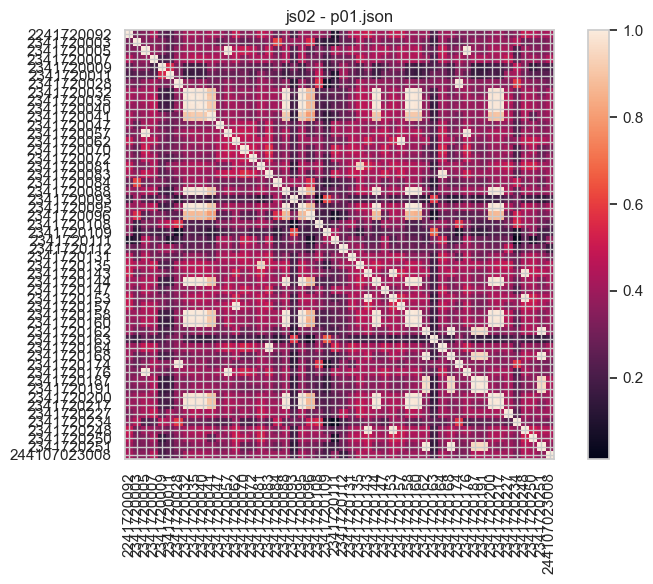

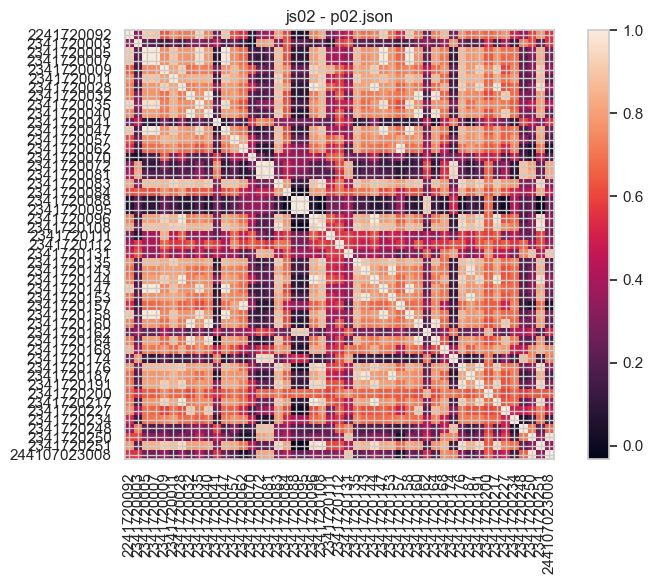

----------------------------------------------------------------------
Total Heatmap Disimpan        : 49
Preview Ditampilkan           : 2


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# ==============================================================================
# FUNCTION HELPER
# ==============================================================================

def build_similarity_matrix(df_meta, embeddings):
    """Membangun matrix similarity dan label nim."""
    sim_matrix = cosine_similarity(embeddings)
    labels = df_meta["nim"].astype(str).tolist()
    return sim_matrix, labels


def plot_heatmap(sim_matrix, labels, title, save_path=None, show=True):
    """Plot heatmap similarity."""
    plt.figure(figsize=(8, 6))

    plt.imshow(sim_matrix)
    plt.colorbar()

    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)

    plt.title(title)
    plt.tight_layout()

    # Simpan gambar
    if save_path:
        plt.savefig(save_path)

    # Kontrol tampil / tidak
    if show:
        plt.show()
    else:
        plt.close()


def generate_heatmaps(input_dir, output_dir, max_preview=2):
    """Generate heatmap per file, tampilkan hanya sebagian."""
    
    os.makedirs(output_dir, exist_ok=True)

    preview_count = 0
    total_saved = 0

    for root, _, files in os.walk(input_dir):
        for file in files:
            if not file.endswith("_embed.pkl"):
                continue

            path = os.path.join(root, file)

            # Load embedding
            df_meta, embeddings, status, _ = load_embedding_file(path)

            if status != "SUCCESS" or df_meta is None or len(df_meta) < 2:
                continue

            modul = df_meta.loc[0, "modul"]
            filename = df_meta.loc[0, "file"]

            # Build similarity
            sim_matrix, labels = build_similarity_matrix(df_meta, embeddings)

            # Path simpan
            save_path = os.path.join(
                output_dir,
                f"{modul}_{filename.replace('.py','')}_heatmap.png"
            )

            # Tentukan apakah ditampilkan
            show_plot = preview_count < max_preview

            # Plot
            plot_heatmap(
                sim_matrix,
                labels,
                title=f"{modul} - {filename}",
                save_path=save_path,
                show=show_plot
            )

            if show_plot:
                preview_count += 1

            total_saved += 1

    return total_saved, preview_count


# ==============================================================================
# RUN & EXECUTION
# ==============================================================================

INPUT_DIR = DIRS['EMBEDDING']
OUTPUT_DIR = os.path.join(DIRS['LOGS'], "heatmap")

print("="*70)
print(f"{' HEATMAP VISUALIZATION ':^70}")
print("-"*70)
print(f"{'Input Directory':<30}: {INPUT_DIR}")
print(f"{'Output Directory':<30}: {OUTPUT_DIR}")

total_saved, preview_count = generate_heatmaps(
    INPUT_DIR,
    OUTPUT_DIR,
    max_preview=2
)

print("-"*70)
print(f"{'Total Heatmap Disimpan':<30}: {total_saved}")
print(f"{'Preview Ditampilkan':<30}: {preview_count}")
print("="*70)

## Euclidean

In [18]:
import os
import pickle
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.metrics.pairwise import euclidean_distances

# ==============================================================================
# FUNCTION HELPER
# ==============================================================================

def load_embedding_file(filepath):
    """
    Load file embedding hasil Graph2Vec.
    """
    try:
        with open(filepath, "rb") as f:
            data = pickle.load(f)

        metadata = pd.DataFrame(data["metadata"])
        embeddings = np.array(data["embeddings"])

        return metadata, embeddings, "SUCCESS", ""

    except Exception as e:
        return None, None, "FAILED", str(e)


def collect_embedding_files(input_dir):
    """
    Mengumpulkan semua file embedding.
    """
    files = []

    for root, _, filenames in os.walk(input_dir):
        for file in filenames:
            if file.endswith("_embed.pkl"):
                files.append(os.path.join(root, file))

    return sorted(files)


def euclidean_to_similarity(distance):
    """
    Konversi Euclidean Distance -> Similarity (%)

    Semakin kecil distance -> semakin tinggi similarity
    """
    similarity = 1 / (1 + distance)

    return round(similarity * 100, 2)


def calculate_euclidean_similarity(df_meta, embeddings):
    """
    Hitung similarity menggunakan Euclidean Distance.
    """

    results = []

    if len(df_meta) < 2:
        return pd.DataFrame()

    # Matrix distance
    dist_matrix = euclidean_distances(embeddings)

    for i in range(len(df_meta)):
        for j in range(i + 1, len(df_meta)):

            nim_1 = df_meta.loc[i, "nim"]
            nim_2 = df_meta.loc[j, "nim"]

            modul = df_meta.loc[i, "modul"]
            file = df_meta.loc[i, "file"]

            distance = float(dist_matrix[i, j])

            similarity = euclidean_to_similarity(distance)

            results.append({
                "modul": modul,
                "file": file,
                "nim_1": nim_1,
                "nim_2": nim_2,
                "euclidean_distance": round(distance, 6),
                "similarity_score": similarity
            })

    df_result = pd.DataFrame(results)

    if not df_result.empty:
        df_result = df_result.sort_values(
            by="similarity_score",
            ascending=False
        )

    return df_result


def categorize_similarity(score):
    """
    Kategori similarity.
    """

    if score >= 90:
        return "Sangat Tinggi"

    elif score >= 80:
        return "Tinggi"

    elif score >= 65:
        return "Sedang"

    return "Rendah"

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Euclidean Similarity dijalankan pada {timestamp}")

✅ Helper functions untuk Euclidean Similarity dijalankan pada 2026-05-26 05:02:12


In [19]:
# ==============================================================================
# RUN / EXECUTION
# ==============================================================================

INPUT_DIR = DIRS['EMBEDDING']

RESULTS['EUCLIDEAN'] = os.path.join(
    DIRS['LOGS'],
    "12_euclidean_similarity.xlsx"
)

OUTPUT_PATH = RESULTS['EUCLIDEAN']

all_files = collect_embedding_files(INPUT_DIR)

logs = []
all_similarity = []

print("=" * 70)
print(f"{' EUCLIDEAN DISTANCE SIMILARITY ':^70}")
print("=" * 70)

print(f"{'Input Directory':<35}: {INPUT_DIR}")
print(f"{'Total Embedding File':<35}: {len(all_files)}")

print("-" * 70)

for filepath in tqdm(all_files, desc="Euclidean Similarity", unit="file"):

    filename = os.path.basename(filepath)

    df_meta, embeddings, status, msg = load_embedding_file(filepath)

    # --------------------------------------------------------------------------
    # VALIDASI LOAD
    # --------------------------------------------------------------------------

    if status != "SUCCESS":

        logs.append({
            "file": filename,
            "status": "FAILED",
            "keterangan": msg
        })

        continue

    # --------------------------------------------------------------------------
    # VALIDASI JUMLAH GRAPH
    # --------------------------------------------------------------------------

    if df_meta is None or len(df_meta) < 2:

        logs.append({
            "file": filename,
            "status": "SKIPPED",
            "keterangan": "Graph < 2"
        })

        continue

    # --------------------------------------------------------------------------
    # CALCULATE SIMILARITY
    # --------------------------------------------------------------------------

    try:

        df_sim = calculate_euclidean_similarity(
            df_meta,
            embeddings
        )

        if not df_sim.empty:

            df_sim["kategori"] = df_sim["similarity_score"].apply(
                categorize_similarity
            )

            all_similarity.append(df_sim)

            logs.append({
                "file": filename,
                "status": "SUCCESS",
                "keterangan": f"{len(df_sim)} pasangan"
            })

        else:

            logs.append({
                "file": filename,
                "status": "SKIPPED",
                "keterangan": "Empty similarity"
            })

    except Exception as e:

        logs.append({
            "file": filename,
            "status": "FAILED",
            "keterangan": str(e)
        })

print(f"{' PROSES SELESAI ':=^70}")
timestamp_finish = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Diproses pada: {timestamp_finish}")

                    EUCLIDEAN DISTANCE SIMILARITY                     
Input Directory                    : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\09_Graph2vec_Embedding
Total Embedding File               : 49
----------------------------------------------------------------------


Euclidean Similarity:   0%|          | 0/49 [00:00<?, ?file/s]

=========================== PROSES SELESAI ===========================
Diproses pada: 2026-05-26 05:02:23


In [20]:
# SUMMARY & REPORTING
# ==============================================================================

df_logs = pd.DataFrame(logs)
if all_similarity:
    df_similarity = pd.concat(all_similarity, ignore_index=True)
else:
    df_similarity = pd.DataFrame()

# ------------------------------------------------------------------------------
# BASIC SUMMARY
total_files = len(all_files)

success = (df_logs["status"] == "SUCCESS").sum()
failed = (df_logs["status"] == "FAILED").sum()
skipped = (df_logs["status"] == "SKIPPED").sum()

success_rate = (
    success / total_files * 100
    if total_files > 0 else 0
)

print("=" * 75)
print(f"{' RINGKASAN EUCLIDEAN SIMILARITY ':^75}")
print("=" * 75)

print(f"{'Total File Embedding':<40}: {total_files}")
print(f"{'SUCCESS':<40}: {success}")
print(f"{'FAILED':<40}: {failed}")
print(f"{'SKIPPED':<40}: {skipped}")
print(f"{'Success Rate':<40}: {success_rate:.2f}%")

print("-" * 75)

# ------------------------------------------------------------------------------
# SIMILARITY SUMMARY
if not df_similarity.empty:

    total_pairs = len(df_similarity)

    avg_similarity = df_similarity["similarity_score"].mean()
    min_similarity = df_similarity["similarity_score"].min()
    max_similarity = df_similarity["similarity_score"].max()

    print(f"{'Total Pasangan Dibandingkan':<40}: {total_pairs}")
    print(f"{'Rata-rata Similarity':<40}: {avg_similarity:.2f}%")
    print(f"{'Similarity Minimum':<40}: {min_similarity:.2f}%")
    print(f"{'Similarity Maximum':<40}: {max_similarity:.2f}%")

    print("-" * 75)

    # --------------------------------------------------------------------------
    # DISTRIBUSI KATEGORI
    print("Distribusi Kategori Similarity:\n")

    print(
        df_similarity["kategori"]
        .value_counts()
    )

    print("-" * 75)

    # --------------------------------------------------------------------------
    # TOP HIGH SIMILARITY
    print("\nTOP 10 SIMILARITY TERTINGGI:\n")
    display(
        df_similarity
        .sort_values(by="similarity_score", ascending=False)
        .head(10)
    )

    # --------------------------------------------------------------------------
    # TOP LOW SIMILARITY
    print("\nTOP 10 SIMILARITY TERENDAH:\n")
    display(
        df_similarity
        .sort_values(by="similarity_score", ascending=True)
        .head(10)
    )

    # --------------------------------------------------------------------------
    # MODUL SUMMARY
    df_modul = (
        df_similarity
        .groupby("modul")["similarity_score"]
        .mean()
        .reset_index()
        .sort_values(by="similarity_score", ascending=False)
    )

    print("\nMODUL DENGAN KEMIRIPAN TERTINGGI:\n")
    display(df_modul.head(10))

else:
    print("Tidak ada similarity yang berhasil dihitung.")

# ------------------------------------------------------------------------------
# SAVE REPORT
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    df_logs.to_excel(
        writer,
        sheet_name="logs",
        index=False
    )

    if not df_similarity.empty:
        df_similarity.to_excel(
            writer,
            sheet_name="all_similarity",
            index=False
        )

        df_modul.to_excel(
            writer,
            sheet_name="modul_summary",
            index=False
        )

    summary_df = pd.DataFrame([{
        "total_file": total_files,
        "success": success,
        "failed": failed,
        "skipped": skipped,
        "success_rate": round(success_rate, 2),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }])

    summary_df.to_excel(
        writer,
        sheet_name="summary",
        index=False
    )

    # AUTO WIDTH
    for ws in writer.sheets.values():
        for col in ws.columns:
            max_len = 0
            col_letter = col[0].column_letter

            for cell in col:
                if cell.value:
                    max_len = max(
                        max_len,
                        len(str(cell.value))
                    )

            ws.column_dimensions[col_letter].width = min(
                max_len + 2,
                50
            )

print(f"\n📊 Report disimpan di: {OUTPUT_PATH}")
print("\n" + "=" * 75)
timestamp_finish = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Diproses pada: {timestamp_finish}")

                      RINGKASAN EUCLIDEAN SIMILARITY                       
Total File Embedding                    : 49
SUCCESS                                 : 49
FAILED                                  : 0
SKIPPED                                 : 0
Success Rate                            : 100.00%
---------------------------------------------------------------------------
Total Pasangan Dibandingkan             : 53054
Rata-rata Similarity                    : 31.29%
Similarity Minimum                      : 9.68%
Similarity Maximum                      : 94.93%
---------------------------------------------------------------------------
Distribusi Kategori Similarity:

kategori
Rendah           43994
Tinggi            5454
Sedang            2032
Sangat Tinggi     1574
Name: count, dtype: int64
---------------------------------------------------------------------------

TOP 10 SIMILARITY TERTINGGI:



,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
27216,js07,p05.json,2341720011,2341720147,0.053385,94.93,Sangat Tinggi
39408,js11,p03.json,2341720084,2341720174,0.054031,94.87,Sangat Tinggi
39409,js11,p03.json,2341720032,2341720234,0.054964,94.79,Sangat Tinggi
39410,js11,p03.json,2341720072,2341720174,0.056215,94.68,Sangat Tinggi
39411,js11,p03.json,2341720095,2341720164,0.056473,94.65,Sangat Tinggi
39412,js11,p03.json,2341720084,2341720111,0.057100,94.60,Sangat Tinggi
39413,js11,p03.json,2341720072,2341720084,0.057219,94.59,Sangat Tinggi
39414,js11,p03.json,2341720028,2341720070,0.057672,94.55,Sangat Tinggi
39415,js11,p03.json,2341720070,2341720160,0.057792,94.54,Sangat Tinggi
39416,js11,p03.json,2341720088,2341720143,0.058273,94.49,Sangat Tinggi



TOP 10 SIMILARITY TERENDAH:



,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
44016,js11,tp.json,2341720160,2341720251,9.332542,9.68,Rendah
44015,js11,tp.json,2341720111,2341720160,9.235271,9.77,Rendah
44014,js11,tp.json,2341720003,2341720160,9.175379,9.83,Rendah
44013,js11,tp.json,2341720162,2341720168,9.078070,9.92,Rendah
44012,js11,tp.json,2341720062,2341720250,9.042147,9.96,Rendah
44011,js11,tp.json,2341720062,2341720160,9.032452,9.97,Rendah
44010,js11,tp.json,2341720070,2341720168,8.878208,10.12,Rendah
44009,js11,tp.json,2341720135,2341720234,8.858258,10.14,Rendah
44006,js11,tp.json,2341720160,2341720187,8.856284,10.15,Rendah
44008,js11,tp.json,2341720062,2341720108,8.848073,10.15,Rendah



MODUL DENGAN KEMIRIPAN TERTINGGI:



,modul,similarity_score
8,js11,42.897768
5,js07,38.024814
11,js15,35.126152
1,js03,33.281416
0,js02,32.165386
3,js05,31.639152
2,js04,30.081495
10,js14,29.628930
7,js09,28.752301
12,kelompok,21.930762



📊 Report disimpan di: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\12_euclidean_similarity.xlsx

Diproses pada: 2026-05-26 05:02:40


In [21]:
# ==============================================================================
# SAVE PER MODUL (1 SHEET = 1 MODUL)
# ==============================================================================

OUTPUT_PER_MODUL = os.path.join(DIRS['LOGS'], "12a_Euclidean_per_Modul.xlsx")
os.makedirs(os.path.dirname(OUTPUT_PER_MODUL), exist_ok=True)

if df_similarity.empty:
    print("Tidak ada data untuk disimpan per modul")
else:
    with pd.ExcelWriter(OUTPUT_PER_MODUL, engine="openpyxl") as writer:

        for modul in df_similarity['modul'].unique():
            df_mod = df_similarity[df_similarity['modul'] == modul].copy()

            # ------------------------------------------------------------------
            # HITUNG STATISTIK
            # ------------------------------------------------------------------
            siswa_unik = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())
            jumlah_siswa = len(siswa_unik)
            total_pasangan = len(df_mod)
            rata_similarity = df_mod['similarity_score'].mean()

            # ------------------------------------------------------------------
            # URUTKAN DATA
            # ------------------------------------------------------------------
            df_mod = df_mod.sort_values(by="similarity_score", ascending=False)

            # ------------------------------------------------------------------
            # TULIS HEADER (RINGKASAN)
            # ------------------------------------------------------------------
            sheet_name = str(modul)[:31]  # max panjang excel

            df_mod.to_excel(writer, sheet_name=sheet_name, startrow=5, index=False)

            worksheet = writer.sheets[sheet_name]

            worksheet["A1"] = f"MODUL: {modul}"
            worksheet["A2"] = f"Jumlah Siswa Dibandingkan : {jumlah_siswa}"
            worksheet["A3"] = f"Total Pasangan           : {total_pasangan}"
            worksheet["A4"] = f"Rata-rata Kemiripan      : {rata_similarity:.2f}%"

            # ------------------------------------------------------------------
            # AUTO WIDTH
            # ------------------------------------------------------------------
            for col in worksheet.columns:
                max_len = 0
                col_letter = col[0].column_letter
                for cell in col:
                    if cell.value:
                        max_len = max(max_len, len(str(cell.value)))
                worksheet.column_dimensions[col_letter].width = min(max_len + 2, 50)

print(f"\n📊 File per modul disimpan di: {OUTPUT_PER_MODUL}")

# ------------------------------------------------------------------------------
# PREVIEW PER MODUL
# ------------------------------------------------------------------------------

print("\n" + "="*70)
print(f"{' PREVIEW SIMILARITY PER MODUL (EUCLIDEAN) ':^70}")
print("="*70)

if df_similarity.empty:
    print("Tidak ada data untuk ditampilkan")
else:
    # ambil 1–2 modul pertama saja biar tidak terlalu panjang
    modul_list = df_similarity['modul'].unique()[:2]

    for modul in modul_list:
        df_mod = df_similarity[df_similarity['modul'] == modul].copy()

        siswa_unik = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())
        jumlah_siswa = len(siswa_unik)
        total_pasangan = len(df_mod)
        rata_similarity = df_mod['similarity_score'].mean()

        print("\n" + "-"*70)
        print(f"MODUL: {modul}")
        print(f"Jumlah Siswa Dibandingkan : {jumlah_siswa}")
        print(f"Total Pasangan           : {total_pasangan}")
        print(f"Rata-rata Kemiripan      : {rata_similarity:.2f}%")

        print("\nTop 5 Kemiripan Tertinggi:")
        display(
            df_mod.sort_values(by="similarity_score", ascending=False).head(5)
        )

        print("\nTop 5 Kemiripan Terendah:")
        display(
            df_mod.sort_values(by="similarity_score", ascending=True).head(5)
        )


📊 File per modul disimpan di: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\12a_Euclidean_per_Modul.xlsx

               PREVIEW SIMILARITY PER MODUL (EUCLIDEAN)               

----------------------------------------------------------------------
MODUL: js02
Jumlah Siswa Dibandingkan : 52
Total Pasangan           : 6030
Rata-rata Kemiripan      : 32.17%

Top 5 Kemiripan Tertinggi:


,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
3678,js02,p04.json,2341720158,2341720250,0.075401,92.99,Sangat Tinggi
3679,js02,p04.json,2341720032,2341720250,0.075755,92.96,Sangat Tinggi
3680,js02,p04.json,2341720135,2341720251,0.076934,92.86,Sangat Tinggi
3681,js02,p04.json,2341720158,2341720160,0.078881,92.69,Sangat Tinggi
3682,js02,p04.json,2341720158,2341720217,0.079002,92.68,Sangat Tinggi



Top 5 Kemiripan Terendah:


,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
6029,js02,tp.json,2341720062,2341720084,7.040300,12.44,Rendah
6028,js02,tp.json,2341720084,2341720157,7.008398,12.49,Rendah
6027,js02,tp.json,2341720072,2341720084,6.935076,12.60,Rendah
6026,js02,tp.json,2341720143,244107023008,6.899077,12.66,Rendah
6025,js02,tp.json,2341720153,244107023008,6.876253,12.70,Rendah



----------------------------------------------------------------------
MODUL: js03
Jumlah Siswa Dibandingkan : 53
Total Pasangan           : 5939
Rata-rata Kemiripan      : 33.28%

Top 5 Kemiripan Tertinggi:


,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
9712,js03,p04.json,2341720234,244107023008,0.063736,94.01,Sangat Tinggi
9713,js03,p04.json,2341720035,2341720162,0.064974,93.90,Sangat Tinggi
9714,js03,p04.json,2341720191,2341720248,0.066879,93.73,Sangat Tinggi
9715,js03,p04.json,2341720057,2341720234,0.067682,93.66,Sangat Tinggi
9716,js03,p04.json,2341720035,2341720112,0.067989,93.63,Sangat Tinggi



Top 5 Kemiripan Terendah:


,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
11968,js03,tp.json,2341720108,2341720200,7.801233,11.36,Rendah
11967,js03,tp.json,2341720083,2341720250,7.716365,11.47,Rendah
11965,js03,tp.json,2341720011,2341720200,7.630214,11.59,Rendah
11966,js03,tp.json,2341720250,244107023008,7.624471,11.59,Rendah
11964,js03,tp.json,2341720007,2341720108,7.619771,11.60,Rendah
